正在读取PDF...

📄 有效PDF总数：153
📏 5页及以下：0 篇
📏 80页及以上：0 篇

🔍 5页及以下文章名单：

🔍 80页及以上文章名单：


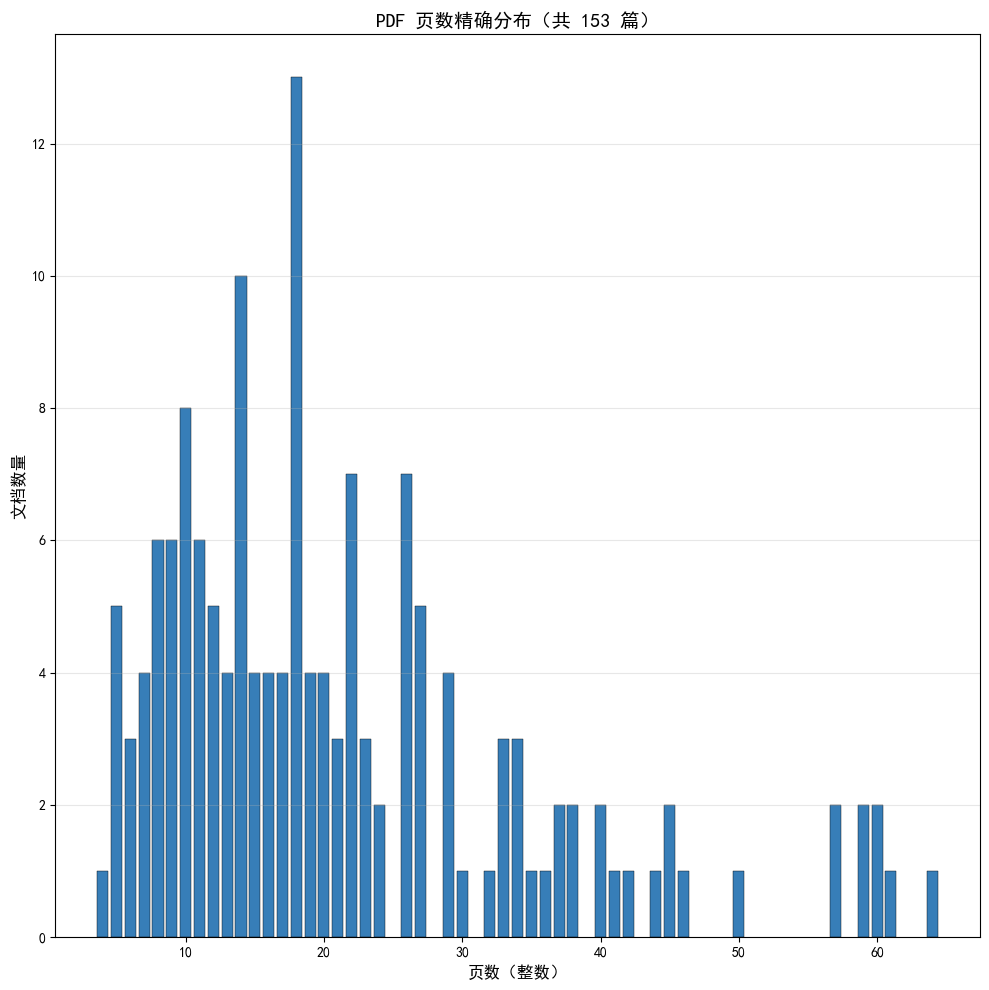

In [7]:
# =============================================================================
# 功能：统计指定文件夹内所有PDF文件的页数，生成页数分布直方图，
#       并列出页数≤3页和≥65页的论文名单（用于筛选异常短或超长文档）。
#       统计结果包括有效PDF总数、短篇和长篇数量及具体文件名。
# =============================================================================
import os
import PyPDF2
import matplotlib.pyplot as plt
from collections import Counter
PDF_FOLDER = r"data/archive/initial_collection/pdf_audit"  # 把这里改成你的PDF文件夹路径


def get_pdf_page_count(pdf_path):
    try:
        with open(pdf_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            return len(reader.pages)
    except:
        return -1  # 损坏文件标记

# 遍历文件夹
all_pages = []
short_papers = []  # ≤5页
long_papers = []   # ≥80页

print("正在读取PDF...")
for fname in os.listdir(PDF_FOLDER):
    if not fname.lower().endswith(".pdf"):
        continue
    path = os.path.join(PDF_FOLDER, fname)
    pages = get_pdf_page_count(path)
    if pages <= 0:
        continue
    all_pages.append(pages)
    if pages <= 3:
        short_papers.append((fname, pages))
    if pages >= 65:
        long_papers.append((fname, pages))

# 统计每页数量
page_counter = Counter(all_pages)
pages_sorted = sorted(page_counter.keys())
counts = [page_counter[p] for p in pages_sorted]

# ===================== 输出结果 =====================
print("\n" + "="*60)
print(f"📄 有效PDF总数：{len(all_pages)}")
print(f"📏 5页及以下：{len(short_papers)} 篇")
print(f"📏 80页及以上：{len(long_papers)} 篇")

print("\n🔍 5页及以下文章名单：")
for name, p in short_papers:
    print(f"  {name}  |  {p}页")

print("\n🔍 80页及以上文章名单：")
for name, p in long_papers:
    print(f"  {name}  |  {p}页")
print("="*60)

# ===================== 画图（每个整数一页柱子） =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(10, 10))

plt.bar(pages_sorted, counts, color='#377eb8', edgecolor='black', linewidth=0.3)
plt.title(f'PDF 页数精确分布（共 {len(all_pages)} 篇）', fontsize=14)
plt.xlabel('页数（整数）', fontsize=12)
plt.ylabel('文档数量', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()